# Zhang et al. (2022) — MobileNetV2 (no TSM) — Controlled T/K Training and Evaluation

Notebook ini adalah versi terkontrol untuk eksperimen **native temporal input length (T)**
dan **train-time/test-time temporal redundancy (K)**.

Konfigurasi utama ada di satu cell:
- `RUN_SEED`: 0 / 42 / 123
- `NATIVE_T`: physical/model input length 1 / 2 / 4 / 8
- `K_TRAIN`: jumlah distinct temporal positions saat training
- `TRAIN_REPEAT_LAYOUT`: `grouped` atau `interleaved`

Interpretasi:
- `K_TRAIN == NATIVE_T` = native-T training tanpa duplication.
- `K_TRAIN < NATIVE_T` = fixed-T matched redundancy training.
- `grouped`: `A A B B C C D D`.
- `interleaved`: `A B C D A B C D`.

Setelah training, notebook dapat mengevaluasi full K-test matrix pada source-pooled,
RWF-2000, UCF-Crime Fighting, dan Bus Violence, serta menyimpan per-clip
probabilities untuk paired/hierarchical bootstrap.


In [15]:
# Jalankan sekali pada awal sesi Colab
!pip -q install ptflops

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import json
import math
import time
import random
import shutil
import platform
import warnings
import zlib
from contextlib import nullcontext
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.mobilenetv2 import InvertedResidual
import torchvision.transforms.functional as TF
from torchvision.transforms import RandomResizedCrop, InterpolationMode

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

print("Python      :", platform.python_version())
print("PyTorch     :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
torchvision : 0.26.0+cu128
CUDA        : True
GPU         : NVIDIA A100-SXM4-40GB


## 1. Konfigurasi eksperimen

Untuk run baru, ubah hanya `RUN_SEED`, `NATIVE_T`, `K_TRAIN`, dan bila diperlukan
`TRAIN_REPEAT_LAYOUT`.

**Run utama M1 yang disarankan**
- fixed `NATIVE_T=8`
- `K_TRAIN in {1,4}` untuk kontrol minimal, atau `{1,2,4}` untuk kurva lengkap
- seeds `{0,42,123}`
- `grouped` sebagai kontrol utama
- `interleaved` terutama pada `K_TRAIN=4` sebagai adjacency/layout control


In [ ]:
# ============================================================
# UBAH HANYA BLOK EKSPERIMEN INI ANTAR-RUN
# ============================================================
RUN_SEED = 42                 # 0, 42, atau 123
NATIVE_T = 8                 # physical/model input length: 1, 2, 4, atau 8
K_TRAIN = 4                  # distinct temporal positions seen during training
TRAIN_REPEAT_LAYOUT = "grouped"   # "grouped" atau "interleaved"; diabaikan jika K_TRAIN == NATIVE_T

# K-matrix evaluation after training.
RUN_K_MATRIX_EVAL = True
K_EVAL_REPEATS = 10          # used only when K_test < NATIVE_T
EVAL_REPEAT_LAYOUTS = ("grouped",) # tambahkan "interleaved" untuk adjacency/layout control
SAMPLING_BASE_SEED = 20260810      # jangan bergantung pada RUN_SEED

# Extended held-out evaluation used in the manuscript.
INCLUDE_UCF_BV = True
ALLOW_BUILD_HELDOUT_CACHE = True

# ============================================================
# FIXED STUDY SETTINGS
# ============================================================
VALID_SEEDS = (0, 42, 123)
VALID_T = (1, 2, 4, 8)
VALID_LAYOUTS = ("grouped", "interleaved")

USE_TSM = False
BASE_MODEL_VARIANT = "mobilenet_v2"

if RUN_SEED not in VALID_SEEDS:
    raise ValueError(f"RUN_SEED harus salah satu dari {VALID_SEEDS}.")

if NATIVE_T not in VALID_T:
    raise ValueError(f"NATIVE_T harus salah satu dari {VALID_T}.")

if K_TRAIN not in VALID_T or K_TRAIN > NATIVE_T or NATIVE_T % K_TRAIN != 0:
    raise ValueError(
        "K_TRAIN harus salah satu {1,2,4,8}, K_TRAIN <= NATIVE_T, "
        "dan harus membagi NATIVE_T."
    )

if TRAIN_REPEAT_LAYOUT not in VALID_LAYOUTS:
    raise ValueError(f"TRAIN_REPEAT_LAYOUT harus salah satu dari {VALID_LAYOUTS}.")

for layout in EVAL_REPEAT_LAYOUTS:
    if layout not in VALID_LAYOUTS:
        raise ValueError(f"Layout evaluasi tidak valid: {layout}")

TRAIN_LAYOUT_EFFECTIVE = (
    "native" if K_TRAIN == NATIVE_T else TRAIN_REPEAT_LAYOUT
)

K_TEST_VALUES = tuple(
    k for k in VALID_T
    if k <= NATIVE_T and NATIVE_T % k == 0
)

MODEL_VARIANT = (
    f"{BASE_MODEL_VARIANT}_T{NATIVE_T}_Ktrain{K_TRAIN}_{TRAIN_LAYOUT_EFFECTIVE}"
)

SEEDS = [RUN_SEED]

# ============================================================
# PATHS
# ============================================================
DATA_ROOT = Path("/content/drive/MyDrive/Data")
MODELS_ROOT = Path("/content/drive/MyDrive/Models")
CACHE_DIR = MODELS_ROOT / "new_saved_dataset"
HELDOUT_CACHE_DIR = MODELS_ROOT / "heldout_cache_rgb64_v2"
BENCHMARK_ROOT = Path("/content/drive/MyDrive/Benchmark")

OUTPUT_DIR = (
    MODELS_ROOT
    / "Comparators"
    / f"{MODEL_VARIANT}_Seed{RUN_SEED}_v1"
)

TRAINVAL_DIR = DATA_ROOT / "TrainVal" / "Gabung"

TEST_SPECS = {
    "HF": {
        "raw_dir": DATA_ROOT / "Testing" / "HockeyFight",
        "cache_name": "HockeyFight",
        "cache_dir": CACHE_DIR,
    },
    "MF": {
        "raw_dir": DATA_ROOT / "Testing" / "MovieFight",
        "cache_name": "MovieFight",
        "cache_dir": CACHE_DIR,
    },
    "VCF": {
        "raw_dir": DATA_ROOT / "Testing" / "ViolentFlow",
        "cache_name": "ViolentFlow",
        "cache_dir": CACHE_DIR,
    },
    "AVDV": {
        "raw_dir": DATA_ROOT / "Testing" / "Automatic",
        "cache_name": "Automatic",
        "cache_dir": CACHE_DIR,
    },
    "SCFD": {
        "raw_dir": DATA_ROOT / "Testing" / "SurveilFight",
        "cache_name": "Surveilence",
        "cache_dir": CACHE_DIR,
    },
    "RLVS": {
        "raw_dir": DATA_ROOT / "Testing" / "Realife",
        "cache_name": "Realife",
        "cache_dir": CACHE_DIR,
    },
    "RWF": {
        "raw_dir": BENCHMARK_ROOT / "RWF",
        "cache_name": "RWF",
        "cache_dir": CACHE_DIR,
    },
}

if INCLUDE_UCF_BV:
    TEST_SPECS.update({
        "UCF": {
            "raw_dir": BENCHMARK_ROOT / "UCF",
            "cache_name": "UCF",
            "cache_dir": HELDOUT_CACHE_DIR,
        },
        "BV": {
            "raw_dir": BENCHMARK_ROOT / "BV",
            "cache_name": "BV",
            "cache_dir": HELDOUT_CACHE_DIR,
        },
    })

POOLED_DATASETS = ["HF", "MF", "VCF", "AVDV", "SCFD", "RLVS"]
HELDOUT_DATASETS = ["RWF"] + (
    ["UCF", "BV"] if INCLUDE_UCF_BV else []
)

# ============================================================
# DATA / MODEL INTERFACE
# ============================================================
CLASS_NAMES = ["NonViolence", "Violence"]
NUM_CLASSES = 2

CACHE_SEQUENCE_LENGTH = 16
RAW_HEIGHT = 64
RAW_WIDTH = 64

NUM_SEGMENTS = NATIVE_T
BACKBONE_INPUT_SIZE = 224
SEGMENT_WIDTH = CACHE_SEQUENCE_LENGTH // NUM_SEGMENTS

if CACHE_SEQUENCE_LENGTH % NUM_SEGMENTS != 0:
    raise ValueError(
        f"CACHE_SEQUENCE_LENGTH={CACHE_SEQUENCE_LENGTH} harus habis "
        f"dibagi NATIVE_T={NUM_SEGMENTS}."
    )

VAL_RATIO = 0.11
FIXED_SPLIT_SEED = 42

PREFER_LEGACY_CACHE = True
LEGACY_CACHE_COLOR_ORDER = "BGR"
AUTO_SCALE_LEGACY_CACHE = True

# ============================================================
# ZHANG ET AL. 2022 — METHOD-SPECIFIC TRAINING RECIPE
# ============================================================
MAX_EPOCHS = 100
BATCH_SIZE = 8

LEARNING_RATE = 3.75e-4
ADAM_BETAS = (0.9, 0.999)
WEIGHT_DECAY = 0.0
LABEL_SMOOTHING = 0.0

LR_DECAY_EVERY = 2
LR_DECAY_GAMMA = 0.85

SHIFT_DIV = 8
CONSENSUS = "avg"

EXPECTED_TSM_BLOCKS = 0

# ============================================================
# SHARED CONTROLLED STUDY PROTOCOL
# ============================================================
AUGMENTATION = {
    "horizontal_flip_p": 0.5,
    "crop_scale": (0.85, 1.0),
    "crop_ratio": (0.90, 1.10),
    "brightness": 0.12,
    "contrast": 0.12,
    "saturation": 0.08,
}

SELECTION_METRIC = "f1_macro"
GRAD_CLIP_NORM = 5.0

NUM_WORKERS = 2
USE_AMP = False

SKIP_COMPLETED_RUNS = True
RESUME_INTERRUPTED_RUNS = True

# Comparator runs use the full 100-epoch schedule.
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 20

BOOTSTRAP_SAMPLES = 1000
LATENCY_WARMUP = 50
LATENCY_RUNS = 200

SMOKE_TEST = False
if SMOKE_TEST:
    MAX_EPOCHS = 2
    BOOTSTRAP_SAMPLES = 100
    K_EVAL_REPEATS = 2
    print("⚠️ SMOKE_TEST aktif: hasil tidak boleh dipakai di paper.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
HELDOUT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Model variant      :", MODEL_VARIANT)
print("Use TSM            :", USE_TSM)
print("Training seed      :", RUN_SEED)
print("Fixed split seed   :", FIXED_SPLIT_SEED)
print("Physical/native T  :", NATIVE_T)
print("K_train            :", K_TRAIN)
print("Training layout    :", TRAIN_LAYOUT_EFFECTIVE)
print("K_test values      :", K_TEST_VALUES)
print("Eval layouts       :", EVAL_REPEAT_LAYOUTS)
print("Batch size         :", BATCH_SIZE)
print("Initial LR         :", LEARNING_RATE)
print("Shift div          :", SHIFT_DIV if USE_TSM else "N/A")
print("Output             :", OUTPUT_DIR)


Model variant      : mobilenet_v2_T8_Ktrain4_grouped
Use TSM            : False
Training seed      : 42
Fixed split seed   : 42
Physical/native T  : 8
K_train            : 4
Training layout    : grouped
K_test values      : (1, 2, 4, 8)
Eval layouts       : ('grouped',)
Batch size         : 8
Initial LR         : 0.000375
Shift div          : N/A
Output             : /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1


## 2. Reproducibility

In [19]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
AMP_DTYPE = (
    torch.bfloat16
    if AMP_ENABLED and torch.cuda.is_bf16_supported()
    else torch.float16
)

def amp_context():
    if not AMP_ENABLED:
        return nullcontext()
    return torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=True)

def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def assert_finite_tensor(name: str, tensor: torch.Tensor):
    if not torch.isfinite(tensor).all():
        raise FloatingPointError(f"{name} mengandung NaN/Inf.")

def safe_torch_load(path: Path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    raise TypeError(type(value).__name__)

set_global_seed(FIXED_SPLIT_SEED)
print("Device:", DEVICE, "| AMP:", AMP_ENABLED)

Device: cuda | AMP: False


## 3. Resolve shared 16-frame caches

Semua kondisi T/K menggunakan shared 16-frame cache yang sama.
Source tests, RWF-2000, UCF-Crime Fighting, dan Bus Violence memakai resolver
cache yang sama; cache RGB-v2 diprioritaskan, legacy cache tetap didukung.


In [20]:
VIDEO_EXTENSIONS = {
    ".mp4", ".avi", ".mov", ".mkv",
    ".mpeg", ".mpg", ".webm",
}

NONVIOLENCE_ALIASES = (
    "NonViolence", "Non-Violence", "Non_Violence",
    "Nonviolent", "NonViolent", "NonFight", "Non-Fight",
    "Non_Fight", "Normal", "NormalVideos", "Normal_Videos",
)

VIOLENCE_ALIASES = (
    "Violence", "Violent", "Fight", "Fighting",
    "FightVideos", "ViolentVideos", "Abnormal",
)

def _direct_subdirs(root: Path) -> Dict[str, Path]:
    if not root.exists():
        return {}
    return {p.name: p for p in root.iterdir() if p.is_dir()}

def _resolve_class_dir(
    root: Path,
    aliases: Tuple[str, ...],
    canonical_name: str,
) -> Path:
    subdirs = _direct_subdirs(root)
    lower_map = {name.lower(): path for name, path in subdirs.items()}

    matches = []
    for alias in aliases:
        candidate = lower_map.get(alias.lower())
        if candidate is not None and candidate not in matches:
            matches.append(candidate)

    if len(matches) != 1:
        raise RuntimeError(
            f"Tidak dapat menentukan folder kelas {canonical_name} pada {root}.\n"
            f"Matches: {[p.name for p in matches]}\n"
            f"Available: {sorted(subdirs.keys())}"
        )
    return matches[0]

def list_videos(dataset_dir: Path) -> List[Tuple[Path, int]]:
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory tidak ditemukan: {dataset_dir}")

    class_dirs = {
        0: _resolve_class_dir(
            dataset_dir, NONVIOLENCE_ALIASES, "NonViolence"
        ),
        1: _resolve_class_dir(
            dataset_dir, VIOLENCE_ALIASES, "Violence"
        ),
    }

    records = []
    for label_idx, class_dir in class_dirs.items():
        files = sorted(
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
        )
        if not files:
            raise RuntimeError(f"Tidak ada video pada {class_dir}")
        records.extend((p, label_idx) for p in files)

    return records

def extract_uniform_rgb_frames(
    video_path: Path,
    sequence_length: int = CACHE_SEQUENCE_LENGTH,
    height: int = RAW_HEIGHT,
    width: int = RAW_WIDTH,
) -> Optional[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None

    positions = np.linspace(
        0, max(frame_count - 1, 0), sequence_length
    ).astype(int)

    frames = []
    for pos in positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(pos))
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frame_rgb = cv2.resize(
            frame_rgb,
            (width, height),
            interpolation=cv2.INTER_LINEAR,
        )
        frames.append(frame_rgb.astype(np.float32) / 255.0)

    cap.release()

    if not frames:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1].copy())

    return np.stack(
        frames[:sequence_length], axis=0
    ).astype(np.float32)

def build_rgb_cache(
    raw_dir: Path,
    cache_name: str,
    cache_dir: Path,
):
    cache_dir.mkdir(parents=True, exist_ok=True)

    feature_path = cache_dir / f"{cache_name}_rgb64_v2_features.npy"
    label_path = cache_dir / f"{cache_name}_rgb64_v2_labels.npy"
    paths_path = cache_dir / f"{cache_name}_rgb64_v2_paths.json"

    records = list_videos(raw_dir)
    if not records:
        raise RuntimeError(f"Tidak ada video pada {raw_dir}")

    n_requested = len(records)
    temp_path = cache_dir / f".{cache_name}_tmp_features.npy"
    if temp_path.exists():
        temp_path.unlink()

    temp = np.lib.format.open_memmap(
        temp_path,
        mode="w+",
        dtype=np.float32,
        shape=(
            n_requested,
            CACHE_SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        ),
    )

    labels_buffer = np.empty(n_requested, dtype=np.int64)
    valid_paths, failed_paths = [], []
    valid_count = 0

    for video_path, label in tqdm(
        records,
        desc=f"Build cache {cache_name}",
        unit="video",
    ):
        clip = extract_uniform_rgb_frames(video_path)
        if clip is None:
            failed_paths.append(str(video_path))
            continue

        temp[valid_count] = clip
        labels_buffer[valid_count] = int(label)
        valid_paths.append(str(video_path))
        valid_count += 1

    temp.flush()
    del temp

    if valid_count == 0:
        if temp_path.exists():
            temp_path.unlink()
        raise RuntimeError(f"Semua video gagal didekode untuk {cache_name}.")

    temp_read = np.load(temp_path, mmap_mode="r")
    final = np.lib.format.open_memmap(
        feature_path,
        mode="w+",
        dtype=np.float32,
        shape=(
            valid_count,
            CACHE_SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        ),
    )

    chunk_size = 16
    for start in range(0, valid_count, chunk_size):
        end = min(start + chunk_size, valid_count)
        final[start:end] = temp_read[start:end]

    final.flush()
    del final, temp_read

    np.save(label_path, labels_buffer[:valid_count])

    with open(paths_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "paths": valid_paths,
                "failed": failed_paths,
                "n_requested": n_requested,
                "n_valid": valid_count,
                "color_order": "RGB",
                "sequence_length": CACHE_SEQUENCE_LENGTH,
                "height": RAW_HEIGHT,
                "width": RAW_WIDTH,
            },
            f,
            indent=2,
        )

    if temp_path.exists():
        temp_path.unlink()

    print(
        f"Saved: {feature_path} | "
        f"shape=({valid_count},{CACHE_SEQUENCE_LENGTH},{RAW_HEIGHT},{RAW_WIDTH},3)"
    )
    return feature_path, label_path, "RGB"

def resolve_cache(
    raw_dir: Path,
    cache_name: str,
    cache_dir: Path,
):
    cache_dir.mkdir(parents=True, exist_ok=True)

    v2_features = cache_dir / f"{cache_name}_rgb64_v2_features.npy"
    v2_labels = cache_dir / f"{cache_name}_rgb64_v2_labels.npy"

    legacy_features = cache_dir / f"{cache_name}_features.npy"
    legacy_labels = cache_dir / f"{cache_name}_labels.npy"

    if v2_features.exists() and v2_labels.exists():
        return v2_features, v2_labels, "RGB"

    if (
        PREFER_LEGACY_CACHE
        and legacy_features.exists()
        and legacy_labels.exists()
    ):
        print(
            f"Using legacy cache for {cache_name}; "
            f"{LEGACY_CACHE_COLOR_ORDER}→RGB conversion will be applied."
        )
        return (
            legacy_features,
            legacy_labels,
            LEGACY_CACHE_COLOR_ORDER,
        )

    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Cache dan raw directory tidak ditemukan untuk {cache_name}: {raw_dir}"
        )

    if (
        cache_dir == HELDOUT_CACHE_DIR
        and not ALLOW_BUILD_HELDOUT_CACHE
    ):
        raise FileNotFoundError(
            f"Held-out cache {cache_name} tidak ada dan "
            "ALLOW_BUILD_HELDOUT_CACHE=False."
        )

    return build_rgb_cache(raw_dir, cache_name, cache_dir)

TRAIN_STORE = resolve_cache(
    TRAINVAL_DIR,
    "trainval",
    CACHE_DIR,
)

TEST_STORES = {
    dataset_name: resolve_cache(
        Path(spec["raw_dir"]),
        str(spec["cache_name"]),
        Path(spec["cache_dir"]),
    )
    for dataset_name, spec in TEST_SPECS.items()
}

print("Train store:", TRAIN_STORE)
for name, store in TEST_STORES.items():
    print(name, "->", store)


Using legacy cache for trainval; BGR→RGB conversion will be applied.
Using legacy cache for HockeyFight; BGR→RGB conversion will be applied.
Using legacy cache for MovieFight; BGR→RGB conversion will be applied.
Using legacy cache for ViolentFlow; BGR→RGB conversion will be applied.
Using legacy cache for Automatic; BGR→RGB conversion will be applied.
Using legacy cache for Surveilence; BGR→RGB conversion will be applied.
Using legacy cache for Realife; BGR→RGB conversion will be applied.
Using legacy cache for RWF; BGR→RGB conversion will be applied.
Train store: (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_labels.npy'), 'BGR')
HF -> (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/HockeyFight_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models

## 4. Controlled T/K sampling + shared augmentation

Sampling memisahkan:
1. **physical T** — jumlah posisi yang benar-benar diproses model;
2. **K** — jumlah distinct temporal positions di dalam physical T;
3. **repetition layout** — grouped atau interleaved.

`K=T` secara eksplisit mereproduksi native-T segment-center evaluation dari
notebook asli. Untuk `K<T`, K posisi dipilih pada native-T grid lalu diulang
equal-weight hingga panjang input kembali ke T. Evaluation sampling menggunakan
seed tetap yang independen dari checkpoint seed.


In [21]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406], dtype=torch.float32
).view(1, 3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225], dtype=torch.float32
).view(1, 3, 1, 1)

class ClipConsistentAugment:
    def __init__(self, config: Dict):
        self.flip_p = float(config["horizontal_flip_p"])
        self.crop_scale = tuple(config["crop_scale"])
        self.crop_ratio = tuple(config["crop_ratio"])
        self.brightness = float(config["brightness"])
        self.contrast = float(config["contrast"])
        self.saturation = float(config["saturation"])

    def __call__(self, clip: torch.Tensor) -> torch.Tensor:
        if torch.rand(()) < self.flip_p:
            clip = TF.hflip(clip)

        i, j, h, w = RandomResizedCrop.get_params(
            clip[0],
            scale=self.crop_scale,
            ratio=self.crop_ratio,
        )

        clip = TF.resized_crop(
            clip, i, j, h, w,
            size=[RAW_HEIGHT, RAW_WIDTH],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        if self.brightness > 0:
            factor = float(
                torch.empty(1).uniform_(
                    1 - self.brightness,
                    1 + self.brightness
                )
            )
            clip = TF.adjust_brightness(clip, factor)

        if self.contrast > 0:
            factor = float(
                torch.empty(1).uniform_(
                    1 - self.contrast,
                    1 + self.contrast
                )
            )
            clip = TF.adjust_contrast(clip, factor)

        if self.saturation > 0:
            factor = float(
                torch.empty(1).uniform_(
                    1 - self.saturation,
                    1 + self.saturation
                )
            )
            clip = TF.adjust_saturation(clip, factor)

        return clip.clamp_(0.0, 1.0)

TRAIN_AUGMENT = ClipConsistentAugment(AUGMENTATION)



def stable_dataset_code(name: str) -> int:
    return int(zlib.crc32(name.encode("utf-8")) & 0xFFFFFFFF)

def native_base_indices(training: bool) -> np.ndarray:
    """Return one raw-cache frame index for each physical/native T position."""
    offsets = []

    for segment_id in range(NUM_SEGMENTS):
        start = segment_id * SEGMENT_WIDTH

        if training:
            offset = np.random.randint(0, SEGMENT_WIDTH)
        else:
            offset = SEGMENT_WIDTH // 2

        offsets.append(start + offset)

    return np.asarray(offsets, dtype=np.int64)

def _select_unique_t_positions(
    k_unique: int,
    training: bool,
    dataset_name: str,
    source_idx: int,
    repeat_id: int,
) -> np.ndarray:
    if k_unique == NUM_SEGMENTS:
        return np.arange(NUM_SEGMENTS, dtype=np.int64)

    if (
        k_unique <= 0
        or k_unique > NUM_SEGMENTS
        or NUM_SEGMENTS % k_unique != 0
    ):
        raise ValueError(
            f"K={k_unique} harus positif, <= T={NUM_SEGMENTS}, "
            "dan membagi T."
        )

    bin_width = NUM_SEGMENTS // k_unique
    selected = []

    if training:
        for bin_id in range(k_unique):
            start = bin_id * bin_width
            stop = start + bin_width
            selected.append(
                int(np.random.randint(start, stop))
            )
    else:
        # Deliberately independent of checkpoint/training seed.
        seed_sequence = np.random.SeedSequence(
            [
                int(SAMPLING_BASE_SEED),
                int(repeat_id),
                int(stable_dataset_code(dataset_name)),
                int(source_idx),
                int(k_unique),
                int(NUM_SEGMENTS),
            ]
        )
        rng = np.random.default_rng(seed_sequence)

        for bin_id in range(k_unique):
            start = bin_id * bin_width
            stop = start + bin_width
            selected.append(
                int(rng.integers(start, stop))
            )

    selected = np.asarray(selected, dtype=np.int64)

    if len(np.unique(selected)) != k_unique:
        raise RuntimeError("Jumlah distinct temporal positions tidak sama dengan K.")

    if not np.all(np.diff(selected) > 0):
        raise RuntimeError("Distinct temporal positions harus kronologis sebelum repetition.")

    return selected

def expand_positions(
    unique_positions: np.ndarray,
    repeat_layout: str,
) -> np.ndarray:
    unique_positions = np.asarray(unique_positions, dtype=np.int64)

    if len(unique_positions) == NUM_SEGMENTS:
        return unique_positions.copy()

    if repeat_layout not in VALID_LAYOUTS:
        raise ValueError(f"repeat_layout tidak valid: {repeat_layout}")

    repeat_factor = NUM_SEGMENTS // len(unique_positions)

    if repeat_layout == "grouped":
        expanded = np.repeat(
            unique_positions,
            repeat_factor,
        )
    elif repeat_layout == "interleaved":
        expanded = np.tile(
            unique_positions,
            repeat_factor,
        )
    else:
        raise AssertionError(repeat_layout)

    expanded = np.asarray(expanded, dtype=np.int64)

    if len(expanded) != NUM_SEGMENTS:
        raise RuntimeError("Expanded sequence tidak kembali ke physical T.")

    counts = np.bincount(
        expanded,
        minlength=NUM_SEGMENTS,
    )
    nonzero = counts[counts > 0]

    if (
        len(nonzero) != len(unique_positions)
        or len(np.unique(nonzero)) != 1
    ):
        raise RuntimeError("Equal-weight repetition gagal.")

    return expanded

def select_temporal_indices(
    training: bool,
    source_idx: int,
    dataset_name: str,
    k_unique: int,
    repeat_layout: str,
    repeat_id: int = 0,
) -> np.ndarray:
    """
    Map a 16-frame cache to a physical T-position model input.

    K=T:
        exact native-T route from the original notebooks.

    K<T:
        choose K distinct positions on the native-T grid, then restore
        the physical input length T by grouped or interleaved repetition.
    """
    base_raw_indices = native_base_indices(training=training)

    unique_t_positions = _select_unique_t_positions(
        k_unique=k_unique,
        training=training,
        dataset_name=dataset_name,
        source_idx=int(source_idx),
        repeat_id=int(repeat_id),
    )

    layout = (
        "grouped"
        if k_unique == NUM_SEGMENTS
        else repeat_layout
    )

    expanded_t_positions = expand_positions(
        unique_t_positions,
        repeat_layout=layout,
    )

    chosen_raw_indices = base_raw_indices[
        expanded_t_positions
    ]

    if chosen_raw_indices.shape != (NUM_SEGMENTS,):
        raise RuntimeError(
            f"Expected {NUM_SEGMENTS} indices, got {chosen_raw_indices.shape}"
        )

    return chosen_raw_indices.astype(np.int64)

class NpyVideoSegmentDataset(Dataset):
    def __init__(
        self,
        feature_path: Path,
        label_path: Path,
        indices: Optional[np.ndarray] = None,
        color_order: str = "RGB",
        training: bool = False,
        dataset_name: str = "dataset",
        k_unique: Optional[int] = None,
        repeat_layout: str = "grouped",
        eval_repeat_id: int = 0,
    ):
        self.feature_path = Path(feature_path)
        self.label_path = Path(label_path)
        self.features = np.load(self.feature_path, mmap_mode="r")
        self.labels = np.load(self.label_path, mmap_mode="r").astype(np.int64)

        self.indices = (
            np.arange(len(self.labels), dtype=np.int64)
            if indices is None
            else np.asarray(indices, dtype=np.int64)
        )

        self.color_order = color_order.upper()
        self.training = bool(training)
        self.dataset_name = str(dataset_name)
        self.k_unique = (
            K_TRAIN
            if k_unique is None
            else int(k_unique)
        )
        self.repeat_layout = str(repeat_layout)
        self.eval_repeat_id = int(eval_repeat_id)

        if len(self.features) != len(self.labels):
            raise ValueError(
                f"Feature/label mismatch: {len(self.features)} vs {len(self.labels)}"
            )

        if (
            self.k_unique <= 0
            or self.k_unique > NUM_SEGMENTS
            or NUM_SEGMENTS % self.k_unique != 0
        ):
            raise ValueError(
                f"Invalid K={self.k_unique} for T={NUM_SEGMENTS}."
            )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_idx: int):
        source_idx = int(self.indices[local_idx])

        frames = np.asarray(
            self.features[source_idx],
            dtype=np.float32,
        )
        label = int(self.labels[source_idx])

        expected = (
            CACHE_SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        )
        if frames.shape != expected:
            raise ValueError(
                f"Unexpected clip shape {frames.shape}; expected {expected}"
            )

        if not np.isfinite(frames).all():
            raise ValueError(
                f"NaN/Inf pada source_idx={source_idx}"
            )

        frame_min = float(frames.min())
        frame_max = float(frames.max())

        if (
            AUTO_SCALE_LEGACY_CACHE
            and frame_min >= 0.0
            and frame_max > 1.5
        ):
            if frame_max <= 255.0 + 1e-3:
                frames = frames / 255.0
            else:
                raise ValueError(
                    f"Rentang cache tidak wajar [{frame_min},{frame_max}]"
                )

        if self.color_order == "BGR":
            frames = frames[..., [2, 1, 0]]

        chosen = select_temporal_indices(
            training=self.training,
            source_idx=source_idx,
            dataset_name=self.dataset_name,
            k_unique=self.k_unique,
            repeat_layout=self.repeat_layout,
            repeat_id=self.eval_repeat_id,
        )
        frames = frames[chosen]

        clip = torch.from_numpy(
            np.ascontiguousarray(frames)
        ).permute(0, 3, 1, 2)

        # Clip-consistent augmentation is deliberately applied AFTER duplication.
        # Therefore repeated observations remain repeated under augmentation.
        if self.training:
            clip = TRAIN_AUGMENT(clip)

        clip = (clip - IMAGENET_MEAN) / IMAGENET_STD

        return (
            clip,
            torch.tensor(label, dtype=torch.long),
            source_idx,
        )


def create_fixed_train_val_split():
    _, label_path, _ = TRAIN_STORE

    labels = np.load(
        label_path,
        mmap_mode="r",
    ).astype(np.int64)

    indices = np.arange(
        len(labels),
        dtype=np.int64,
    )

    original_split_path = (
        CACHE_DIR / "split_indices_trainval.npy"
    )

    copied_split_path = (
        OUTPUT_DIR / "fixed_train_val_split_used.npz"
    )

    if original_split_path.exists():
        permutation = np.load(
            original_split_path
        ).astype(np.int64)

        if len(permutation) != len(labels):
            raise ValueError(
                "Jumlah indeks split asli tidak sama dengan jumlah label."
            )

        if set(permutation.tolist()) != set(indices.tolist()):
            raise ValueError(
                "split_indices_trainval.npy bukan permutasi lengkap dataset."
            )

        val_size = int(
            len(labels) * VAL_RATIO
        )
        train_size = (
            len(labels) - val_size
        )

        train_idx = permutation[:train_size]
        val_idx = permutation[train_size:]
        split_source = str(original_split_path)

        print(
            "✅ Menggunakan split asli:",
            original_split_path,
        )

    else:
        fallback_path = (
            OUTPUT_DIR
            / f"fallback_stratified_split_seed{FIXED_SPLIT_SEED}.npz"
        )

        if fallback_path.exists():
            split = np.load(fallback_path)
            train_idx = split["train_idx"]
            val_idx = split["val_idx"]

        else:
            train_idx, val_idx = train_test_split(
                indices,
                test_size=VAL_RATIO,
                random_state=FIXED_SPLIT_SEED,
                shuffle=True,
                stratify=labels,
            )

            np.savez(
                fallback_path,
                train_idx=train_idx,
                val_idx=val_idx,
            )

        split_source = str(fallback_path)

        print(
            "⚠️ Split asli tidak ditemukan; "
            "menggunakan fallback fixed split seed 42."
        )

    np.savez(
        copied_split_path,
        train_idx=np.asarray(train_idx, dtype=np.int64),
        val_idx=np.asarray(val_idx, dtype=np.int64),
        source=np.asarray(split_source),
    )

    for split_name, idx in [
        ("train", train_idx),
        ("validation", val_idx),
    ]:
        values, counts = np.unique(
            labels[idx],
            return_counts=True,
        )
        distribution = {
            CLASS_NAMES[int(v)]: int(c)
            for v, c in zip(values, counts)
        }
        print(
            split_name,
            len(idx),
            distribution,
        )

    print(
        "Split audit saved:",
        copied_split_path,
    )

    return (
        np.asarray(train_idx),
        np.asarray(val_idx),
    )

TRAIN_INDICES, VAL_INDICES = create_fixed_train_val_split()



def build_loaders(training_seed: int):
    train_feature, train_label, train_color = TRAIN_STORE

    train_ds = NpyVideoSegmentDataset(
        train_feature,
        train_label,
        TRAIN_INDICES,
        train_color,
        training=True,
        dataset_name="TrainVal",
        k_unique=K_TRAIN,
        repeat_layout=TRAIN_REPEAT_LAYOUT,
        eval_repeat_id=0,
    )

    val_ds = NpyVideoSegmentDataset(
        train_feature,
        train_label,
        VAL_INDICES,
        train_color,
        training=False,
        dataset_name="Validation",
        k_unique=K_TRAIN,
        repeat_layout=TRAIN_REPEAT_LAYOUT,
        eval_repeat_id=0,
    )

    generator = torch.Generator()
    generator.manual_seed(training_seed)

    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=seed_worker,
        persistent_workers=(NUM_WORKERS > 0),
    )

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        generator=generator,
        drop_last=False,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        drop_last=False,
        **common,
    )

    test_loaders = {}

    for dataset_name, (
        feature_path,
        label_path,
        color_order,
    ) in TEST_STORES.items():

        ds = NpyVideoSegmentDataset(
            feature_path,
            label_path,
            indices=None,
            color_order=color_order,
            training=False,
            dataset_name=dataset_name,
            k_unique=K_TRAIN,
            repeat_layout=TRAIN_REPEAT_LAYOUT,
            eval_repeat_id=0,
        )

        test_loaders[dataset_name] = DataLoader(
            ds,
            shuffle=False,
            drop_last=False,
            **common,
        )

    return (
        train_loader,
        val_loader,
        test_loaders,
    )

# ------------------------------------------------------------
# Protocol audit before any training
# ------------------------------------------------------------
expected_native_eval = np.asarray(
    [
        segment_id * SEGMENT_WIDTH + SEGMENT_WIDTH // 2
        for segment_id in range(NUM_SEGMENTS)
    ],
    dtype=np.int64,
)

observed_native_eval = select_temporal_indices(
    training=False,
    source_idx=0,
    dataset_name="AUDIT",
    k_unique=NUM_SEGMENTS,
    repeat_layout="grouped",
    repeat_id=0,
)

if not np.array_equal(
    expected_native_eval,
    observed_native_eval,
):
    raise RuntimeError(
        "Native-T route tidak mereproduksi deterministic segment-center route."
    )

if NUM_SEGMENTS == 8:
    if not np.array_equal(
        observed_native_eval,
        np.asarray([1, 3, 5, 7, 9, 11, 13, 15]),
    ):
        raise RuntimeError("T=8 direct grid berubah dari protokol lama.")

if K_TRAIN < NUM_SEGMENTS:
    audit_grouped = select_temporal_indices(
        training=False,
        source_idx=17,
        dataset_name="AUDIT",
        k_unique=K_TRAIN,
        repeat_layout="grouped",
        repeat_id=0,
    )
    audit_interleaved = select_temporal_indices(
        training=False,
        source_idx=17,
        dataset_name="AUDIT",
        k_unique=K_TRAIN,
        repeat_layout="interleaved",
        repeat_id=0,
    )
    if sorted(audit_grouped.tolist()) != sorted(audit_interleaved.tolist()):
        raise RuntimeError(
            "Grouped/interleaved audit harus menggunakan multiset frame yang sama."
        )

print("Native deterministic indices:", observed_native_eval.tolist())

train_loader_check, val_loader_check, test_loader_check = (
    build_loaders(SEEDS[0])
)

batch_clip, batch_label, batch_index = next(
    iter(train_loader_check)
)

print(
    "Train batch:",
    batch_clip.shape,
    batch_label.shape,
)

print(
    "Test sizes:",
    {
        k: len(v.dataset)
        for k, v in test_loader_check.items()
    },
)

assert batch_clip.shape[1] == NUM_SEGMENTS
assert_finite_tensor(
    "sanity_train_batch",
    batch_clip,
)

del (
    train_loader_check,
    val_loader_check,
    test_loader_check,
)


✅ Menggunakan split asli: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/split_indices_trainval.npy
train 3278 {'NonViolence': 1604, 'Violence': 1674}
validation 405 {'NonViolence': 189, 'Violence': 216}
Split audit saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1/fixed_train_val_split_used.npz
Native deterministic indices: [1, 3, 5, 7, 9, 11, 13, 15]
Train batch: torch.Size([8, 8, 3, 64, 64]) torch.Size([8])
Test sizes: {'HF': 100, 'MF': 20, 'VCF': 26, 'AVDV': 35, 'SCFD': 30, 'RLVS': 200, 'RWF': 1998, 'UCF': 100, 'BV': 1400}


## 5. Model — MobileNetV2 (no TSM)

Arsitektur dan training recipe dipertahankan dari comparator Zhang et al. (2022).

Notebook ini tidak menyisipkan modul TSM apa pun.


In [22]:
class VideoMobileNetComparator(nn.Module):
    """MobileNetV2 spatial comparator without TSM."""

    def __init__(
        self,
        use_tsm: bool = False,
        pretrained: bool = True,
        num_classes: int = NUM_CLASSES,
    ):
        super().__init__()

        if use_tsm:
            raise ValueError(
                "Notebook ini khusus MobileNetV2 tanpa TSM; USE_TSM harus False."
            )

        self.use_tsm = False
        self.num_segments = NUM_SEGMENTS
        self.tsm_blocks = 0

        weights = (
            MobileNet_V2_Weights.IMAGENET1K_V1
            if pretrained
            else None
        )

        self.base_model = mobilenet_v2(
            weights=weights
        )

        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier[1] = nn.Linear(
            in_features,
            num_classes,
        )

    def forward(self, clip: torch.Tensor) -> torch.Tensor:
        if clip.ndim != 5:
            raise ValueError(
                f"Expected [B,T,C,H,W], got {tuple(clip.shape)}"
            )

        batch_size, seq_len, channels, height, width = clip.shape

        if seq_len != self.num_segments:
            raise ValueError(
                f"Expected {self.num_segments} segments, got {seq_len}"
            )

        x = clip.reshape(
            batch_size * seq_len,
            channels,
            height,
            width,
        )

        x = F.interpolate(
            x,
            size=(BACKBONE_INPUT_SIZE, BACKBONE_INPUT_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        segment_logits = self.base_model(x)
        segment_logits = segment_logits.view(
            batch_size,
            seq_len,
            NUM_CLASSES,
        )

        return segment_logits.mean(dim=1)

def count_parameters(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )
    return total, trainable

def build_optimizer(model: nn.Module):
    return torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=ADAM_BETAS,
        weight_decay=WEIGHT_DECAY,
    )

set_global_seed(SEEDS[0])

audit_model = VideoMobileNetComparator(
    use_tsm=USE_TSM,
    pretrained=True,
).to(DEVICE)

total_params, trainable_params = count_parameters(
    audit_model
)

print("Variant          :", MODEL_VARIANT)
print("Use TSM          :", USE_TSM)
print("Temporal segments:", NUM_SEGMENTS)
print("TSM blocks       :", audit_model.tsm_blocks)
print("Total params     :", f"{total_params:,}")
print("Trainable params :", f"{trainable_params:,}")

dummy = torch.randn(
    2,
    NUM_SEGMENTS,
    3,
    RAW_HEIGHT,
    RAW_WIDTH,
    device=DEVICE,
)

with torch.inference_mode():
    dummy_out = audit_model(dummy)

assert dummy_out.shape == (2, NUM_CLASSES)

if USE_TSM:
    if audit_model.tsm_blocks != EXPECTED_TSM_BLOCKS:
        raise RuntimeError(
            f"Expected {EXPECTED_TSM_BLOCKS} TSM blocks, "
            f"found {audit_model.tsm_blocks}."
        )

del audit_model, dummy, dummy_out
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Variant          : mobilenet_v2_T8_Ktrain4_grouped
Use TSM          : False
Temporal segments: 8
TSM blocks       : 0
Total params     : 2,226,434
Trainable params : 2,226,434


## 6. Metrics, bootstrap, confusion matrix, ROC

In [23]:
def compute_classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
) -> Dict[str, float]:

    precision_cls, recall_cls, f1_cls, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            zero_division=0,
        )
    )

    prevalence = float(np.mean(y_true == 1))

    result = {
        "n": int(len(y_true)),
        "positive_prevalence": prevalence,
        "chance_ap": prevalence,
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "precision_macro": float(
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_macro": float(
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "f1_macro": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "precision_nonviolence": float(precision_cls[0]),
        "recall_nonviolence": float(recall_cls[0]),
        "f1_nonviolence": float(f1_cls[0]),
        "precision_violence": float(precision_cls[1]),
        "recall_violence": float(recall_cls[1]),
        "f1_violence": float(f1_cls[1]),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = float(
            roc_auc_score(
                y_true,
                p_violence,
            )
        )
        result["average_precision"] = float(
            average_precision_score(
                y_true,
                p_violence,
            )
        )
    else:
        result["roc_auc"] = float("nan")
        result["average_precision"] = float("nan")

    return result

@torch.inference_mode()
def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_indices = []
    all_labels = []
    all_predictions = []
    all_probabilities = []

    for clips, labels, indices in loader:
        clips = clips.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        with amp_context():
            logits = model(clips)
            loss = criterion(
                logits,
                labels,
            )

        probs = torch.softmax(
            logits.float(),
            dim=1,
        )

        preds = probs.argmax(dim=1)

        batch_size = labels.size(0)

        total_loss += (
            float(loss.item())
            * batch_size
        )
        total_samples += batch_size

        all_indices.extend(
            np.asarray(indices).tolist()
        )
        all_labels.extend(
            labels.cpu().numpy().tolist()
        )
        all_predictions.extend(
            preds.cpu().numpy().tolist()
        )
        all_probabilities.extend(
            probs.cpu().numpy().tolist()
        )

    y_true = np.asarray(
        all_labels,
        dtype=np.int64,
    )
    y_pred = np.asarray(
        all_predictions,
        dtype=np.int64,
    )
    probs = np.asarray(
        all_probabilities,
        dtype=np.float64,
    )
    sample_indices = np.asarray(
        all_indices,
        dtype=np.int64,
    )

    metrics = compute_classification_metrics(
        y_true,
        y_pred,
        probs[:, 1],
    )

    metrics["loss"] = (
        total_loss
        / max(total_samples, 1)
    )

    return (
        metrics,
        sample_indices,
        y_true,
        y_pred,
        probs,
    )

def bootstrap_ci(
    y_true,
    y_pred,
    p_violence,
    metric_name,
    n_bootstrap,
    seed,
    alpha=0.05,
):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    values = []
    attempts = 0
    max_attempts = max(
        n_bootstrap * 5,
        1000,
    )

    while (
        len(values) < n_bootstrap
        and attempts < max_attempts
    ):
        attempts += 1

        idx = rng.integers(
            0,
            n,
            size=n,
        )

        yt = y_true[idx]
        yp = y_pred[idx]
        pp = p_violence[idx]

        if (
            metric_name in {
                "roc_auc",
                "average_precision",
            }
            and len(np.unique(yt)) < 2
        ):
            continue

        if metric_name == "accuracy":
            value = accuracy_score(yt, yp)

        elif metric_name == "f1_macro":
            value = f1_score(
                yt,
                yp,
                average="macro",
                zero_division=0,
            )

        elif metric_name == "f1_violence":
            value = f1_score(
                yt,
                yp,
                pos_label=1,
                zero_division=0,
            )

        elif metric_name == "roc_auc":
            value = roc_auc_score(
                yt,
                pp,
            )

        elif metric_name == "average_precision":
            value = average_precision_score(
                yt,
                pp,
            )

        else:
            raise ValueError(metric_name)

        values.append(float(value))

    if not values:
        return float("nan"), float("nan")

    return (
        float(
            np.quantile(
                values,
                alpha / 2,
            )
        ),
        float(
            np.quantile(
                values,
                1 - alpha / 2,
            )
        ),
    )

def save_confusion_and_roc(
    y_true,
    y_pred,
    p_violence,
    title_prefix,
    output_dir: Path,
):
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    image = ax.imshow(cm)

    for (row, col), value in np.ndenumerate(cm):
        ax.text(
            col,
            row,
            str(value),
            ha="center",
            va="center",
        )

    ax.set_xticks(
        [0, 1],
        CLASS_NAMES,
    )
    ax.set_yticks(
        [0, 1],
        CLASS_NAMES,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(
        f"{title_prefix} — Confusion Matrix"
    )

    fig.colorbar(
        image,
        ax=ax,
    )
    fig.tight_layout()

    fig.savefig(
        output_dir / "confusion_matrix.png",
        dpi=180,
    )
    plt.close(fig)

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(
            y_true,
            p_violence,
        )

        auc_value = roc_auc_score(
            y_true,
            p_violence,
        )

        fig, ax = plt.subplots(
            figsize=(5, 4)
        )

        ax.plot(
            fpr,
            tpr,
            label=f"AUC={auc_value:.4f}",
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
        )

        ax.set_xlabel(
            "False Positive Rate"
        )
        ax.set_ylabel(
            "True Positive Rate"
        )
        ax.set_title(
            f"{title_prefix} — ROC"
        )
        ax.legend()
        ax.grid(True)
        fig.tight_layout()

        fig.savefig(
            output_dir / "roc_curve.png",
            dpi=180,
        )
        plt.close(fig)

## 7. Training loop

Tidak ada test-set tuning. Checkpoint terbaik dipilih hanya dari validation Macro-F1.

In [24]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc="Train",
        leave=False,
    )

    for clips, labels, _ in progress:
        clips = clips.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with amp_context():
            logits = model(clips)
            loss = criterion(
                logits,
                labels,
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM,
        )

        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        batch_size = labels.size(0)

        running_loss += (
            float(loss.item())
            * batch_size
        )

        correct += int(
            (preds == labels)
            .sum()
            .item()
        )

        total += batch_size

        progress.set_postfix(
            loss=f"{running_loss / max(total,1):.4f}",
            acc=f"{correct / max(total,1):.4f}",
        )

    return {
        "loss": (
            running_loss
            / max(total, 1)
        ),
        "accuracy": (
            correct
            / max(total, 1)
        ),
    }

def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    best_score,
    no_improve_counter,
    history,
    config,
):
    torch.save(
        {
            "epoch": epoch,
            "best_score": best_score,
            "no_improve_counter": no_improve_counter,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "config": config,
        },
        path,
    )

def run_experiment(seed: int):
    run_dir = (
        OUTPUT_DIR
        / MODEL_VARIANT
        / f"seed_{seed}"
    )

    run_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    completed_path = (
        run_dir / "completed.json"
    )

    metrics_path = (
        run_dir / "test_metrics.csv"
    )

    if (
        SKIP_COMPLETED_RUNS
        and completed_path.exists()
        and metrics_path.exists()
    ):
        print(
            "✅ Existing completed run:",
            run_dir,
        )
        return pd.read_csv(
            metrics_path
        )

    set_global_seed(seed)

    train_loader, val_loader, test_loaders = (
        build_loaders(seed)
    )

    model = VideoMobileNetComparator(
        use_tsm=USE_TSM,
        pretrained=True,
    ).to(DEVICE)

    optimizer = build_optimizer(
        model
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=LR_DECAY_EVERY,
        gamma=LR_DECAY_GAMMA,
    )

    criterion = nn.CrossEntropyLoss()

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(
            AMP_ENABLED
            and AMP_DTYPE == torch.float16
        ),
    )

    config = {
        "model_variant": MODEL_VARIANT,
        "method_reference": "Zhang et al., PLOS ONE 2022",
        "seed": seed,
        "fixed_split_seed": FIXED_SPLIT_SEED,
        "cache_sequence_length": CACHE_SEQUENCE_LENGTH,
        "native_t": NATIVE_T,
        "physical_input_length_t": NUM_SEGMENTS,
        "k_train": K_TRAIN,
        "k_validation": K_TRAIN,
        "train_repeat_layout": TRAIN_LAYOUT_EFFECTIVE,
        "sampling_base_seed_for_eval": SAMPLING_BASE_SEED,
        "k_test_values": list(K_TEST_VALUES),
        "eval_repeat_layouts": list(EVAL_REPEAT_LAYOUTS),
        "k_eval_repeats": K_EVAL_REPEATS,
        "backbone": "torchvision MobileNetV2 ImageNet pretrained",
        "use_tsm": USE_TSM,
        "temporal_shift_effective": bool(USE_TSM and NUM_SEGMENTS > 1),
        "shift_div": SHIFT_DIV if USE_TSM else None,
        "consensus": CONSENSUS,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "adam_betas": list(ADAM_BETAS),
        "weight_decay": WEIGHT_DECAY,
        "lr_decay_every": LR_DECAY_EVERY,
        "lr_decay_gamma": LR_DECAY_GAMMA,
        "label_smoothing": LABEL_SMOOTHING,
        "selection_metric": "validation_f1_macro",
        "augmentation": AUGMENTATION,
        "raw_resolution": [RAW_HEIGHT, RAW_WIDTH],
        "model_input_resolution": [
            BACKBONE_INPUT_SIZE,
            BACKBONE_INPUT_SIZE,
        ],
        "source_pooled_datasets": POOLED_DATASETS,
        "heldout_datasets": HELDOUT_DATASETS,
        "protocol_note": (
            "Controlled T/K study. Physical T controls processed positions; "
            "K controls distinct temporal positions while T stays fixed. "
            "For K<T, equal-weight repetition restores the physical T input. "
            "Validation uses the same K/layout as training. "
            "Evaluation temporal sampling is checkpoint-seed independent."
        ),
    }

    with open(
        run_dir / "config.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            config,
            f,
            indent=2,
            default=json_default,
        )

    history = []
    start_epoch = 1
    best_score = -math.inf
    no_improve_counter = 0

    last_path = (
        run_dir / "last.pt"
    )

    best_path = (
        run_dir / "best.pt"
    )

    if (
        RESUME_INTERRUPTED_RUNS
        and last_path.exists()
    ):
        ckpt = safe_torch_load(
            last_path,
            map_location=DEVICE,
        )

        model.load_state_dict(
            ckpt["model_state_dict"]
        )

        optimizer.load_state_dict(
            ckpt["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            ckpt["scheduler_state_dict"]
        )

        scaler.load_state_dict(
            ckpt["scaler_state_dict"]
        )

        start_epoch = (
            int(ckpt["epoch"])
            + 1
        )

        best_score = float(
            ckpt.get(
                "best_score",
                -math.inf,
            )
        )

        no_improve_counter = int(
            ckpt.get(
                "no_improve_counter",
                0,
            )
        )

        history = ckpt.get(
            "history",
            [],
        )

        print(
            f"↩️ Resume seed={seed} "
            f"from epoch {start_epoch}"
        )

    training_start = time.time()

    for epoch in range(
        start_epoch,
        MAX_EPOCHS + 1,
    ):
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
        )

        (
            val_metrics,
            _,
            _,
            _,
            _,
        ) = evaluate_loader(
            model,
            val_loader,
            criterion,
        )

        score = float(
            val_metrics[
                SELECTION_METRIC
            ]
        )

        improved = (
            score
            > best_score + 1e-8
        )

        if improved:
            best_score = score
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_f1_violence": val_metrics["f1_violence"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_average_precision": val_metrics["average_precision"],
            "learning_rate": optimizer.param_groups[0]["lr"],
            "epoch_seconds": time.time() - epoch_start,
        }

        history.append(record)

        pd.DataFrame(
            history
        ).to_csv(
            run_dir / "history.csv",
            index=False,
        )

        save_checkpoint(
            last_path,
            model,
            optimizer,
            scheduler,
            scaler,
            epoch,
            best_score,
            no_improve_counter,
            history,
            config,
        )

        if improved:
            shutil.copy2(
                last_path,
                best_path,
            )

        print(
            f"Epoch {epoch:03d} | "
            f"lr={optimizer.param_groups[0]['lr']:.7f} | "
            f"train loss={train_metrics['loss']:.4f} "
            f"acc={train_metrics['accuracy']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} "
            f"acc={val_metrics['accuracy']:.4f} "
            f"F1macro={val_metrics['f1_macro']:.4f} "
            f"AUC={val_metrics['roc_auc']:.4f} | "
            f"best F1={best_score:.4f}"
        )

        # Fixed paper-derived LR schedule.
        scheduler.step()

        if (
            USE_EARLY_STOPPING
            and no_improve_counter
            >= EARLY_STOP_PATIENCE
        ):
            print(
                "Early stopping aktif dan patience tercapai."
            )
            break

    total_training_seconds = (
        time.time()
        - training_start
    )

    if not best_path.exists():
        raise RuntimeError(
            f"Best checkpoint tidak ditemukan: {best_path}"
        )

    best_ckpt = safe_torch_load(
        best_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        best_ckpt[
            "model_state_dict"
        ]
    )

    model.eval()

    all_rows = []
    pooled_parts = []

    for dataset_name, test_loader in test_loaders.items():
        (
            metrics,
            indices,
            y_true,
            y_pred,
            probs,
        ) = evaluate_loader(
            model,
            test_loader,
            criterion,
        )

        dataset_dir = (
            run_dir
            / "test_results"
            / dataset_name
        )

        dataset_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        pred_df = pd.DataFrame({
            "sample_index": indices,
            "y_true": y_true,
            "y_pred": y_pred,
            "p_nonviolence": probs[:, 0],
            "p_violence": probs[:, 1],
        })

        pred_df.to_csv(
            dataset_dir / "predictions.csv",
            index=False,
        )

        save_confusion_and_roc(
            y_true,
            y_pred,
            probs[:, 1],
            title_prefix=(
                f"{MODEL_VARIANT} "
                f"seed {seed} — {dataset_name}"
            ),
            output_dir=dataset_dir,
        )

        for metric_name in [
            "accuracy",
            "f1_macro",
            "f1_violence",
            "roc_auc",
            "average_precision",
        ]:
            low, high = bootstrap_ci(
                y_true,
                y_pred,
                probs[:, 1],
                metric_name=metric_name,
                n_bootstrap=BOOTSTRAP_SAMPLES,
                seed=(
                    seed * 1000
                    + sum(
                        ord(c)
                        for c in (
                            dataset_name
                            + metric_name
                        )
                    )
                ),
            )

            metrics[
                f"{metric_name}_ci95_low"
            ] = low

            metrics[
                f"{metric_name}_ci95_high"
            ] = high

        metrics.update({
            "variant": MODEL_VARIANT,
                "native_t": NATIVE_T,
                "k_train": K_TRAIN,
                "train_layout": TRAIN_LAYOUT_EFFECTIVE,
            "seed": seed,
            "dataset": dataset_name,
            "best_epoch": int(
                best_ckpt["epoch"]
            ),
            "best_val_f1_macro": float(
                best_ckpt["best_score"]
            ),
            "total_training_seconds": total_training_seconds,
        })

        all_rows.append(metrics)

        if dataset_name in POOLED_DATASETS:
            pooled_part = pred_df.copy()
            pooled_part[
                "dataset"
            ] = dataset_name
            pooled_parts.append(
                pooled_part
            )

    pooled = pd.concat(
        pooled_parts,
        ignore_index=True,
    )

    pooled_metrics = compute_classification_metrics(
        pooled["y_true"].to_numpy(),
        pooled["y_pred"].to_numpy(),
        pooled["p_violence"].to_numpy(),
    )

    pooled_metrics.update({
        "loss": float("nan"),
        "variant": MODEL_VARIANT,
                "native_t": NATIVE_T,
                "k_train": K_TRAIN,
                "train_layout": TRAIN_LAYOUT_EFFECTIVE,
        "seed": seed,
        "dataset": "ALL_TESTS_POOLED",
        "best_epoch": int(
            best_ckpt["epoch"]
        ),
        "best_val_f1_macro": float(
            best_ckpt["best_score"]
        ),
        "total_training_seconds": total_training_seconds,
    })

    all_rows.append(
        pooled_metrics
    )

    (
        run_dir
        / "test_results"
    ).mkdir(
        parents=True,
        exist_ok=True,
    )

    pooled.to_csv(
        run_dir
        / "test_results"
        / "predictions_ALL_TESTS_POOLED.csv",
        index=False,
    )

    metrics_df = pd.DataFrame(
        all_rows
    )

    metrics_df.to_csv(
        metrics_path,
        index=False,
    )

    hist = pd.DataFrame(
        history
    )

    if not hist.empty:
        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        ax.plot(
            hist["epoch"],
            hist["train_loss"],
            label="Train loss",
        )

        ax.plot(
            hist["epoch"],
            hist["val_loss"],
            label="Validation loss",
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(
            f"{MODEL_VARIANT}, seed={seed}"
        )
        ax.grid(True)
        ax.legend()
        fig.tight_layout()

        fig.savefig(
            run_dir / "loss_curve.png",
            dpi=180,
        )
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        ax.plot(
            hist["epoch"],
            hist["train_accuracy"],
            label="Train accuracy",
        )

        ax.plot(
            hist["epoch"],
            hist["val_accuracy"],
            label="Validation accuracy",
        )

        ax.plot(
            hist["epoch"],
            hist["val_f1_macro"],
            label="Validation Macro-F1",
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_title(
            f"{MODEL_VARIANT}, seed={seed}"
        )
        ax.grid(True)
        ax.legend()
        fig.tight_layout()

        fig.savefig(
            run_dir / "accuracy_f1_curve.png",
            dpi=180,
        )
        plt.show()
        plt.close(fig)

    with open(
        completed_path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            {
                "variant": MODEL_VARIANT,
                "native_t": NATIVE_T,
                "k_train": K_TRAIN,
                "train_layout": TRAIN_LAYOUT_EFFECTIVE,
                "seed": seed,
                "best_epoch": int(
                    best_ckpt["epoch"]
                ),
                "best_val_f1_macro": float(
                    best_ckpt["best_score"]
                ),
                "total_training_seconds": total_training_seconds,
            },
            f,
            indent=2,
        )

    return metrics_df

## 8. Jalankan satu training seed

Checkpoint dipilih berdasarkan validation Macro-F1 seperti comparator asli.
Validation selalu menggunakan `K=K_TRAIN` dan layout yang sama dengan training,
sehingga kontrol matched-redundancy tidak dipilih menggunakan full-diversity validation.


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 001 | lr=0.0003750 | train loss=0.5550 acc=0.7441 | val loss=0.5226 acc=0.7333 F1macro=0.7287 AUC=0.8838 | best F1=0.7287


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 002 | lr=0.0003750 | train loss=0.4256 acc=0.8081 | val loss=0.3552 acc=0.8444 F1macro=0.8440 AUC=0.9250 | best F1=0.8440


Train:   0%|          | 0/410 [00:00<?, ?it/s]

...

Epoch 098 | lr=0.0000002 | train loss=0.0062 acc=0.9973 | val loss=0.3563 acc=0.9432 F1macro=0.9428 AUC=0.9843 | best F1=0.9529


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 099 | lr=0.0000001 | train loss=0.0047 acc=0.9976 | val loss=0.3436 acc=0.9457 F1macro=0.9453 AUC=0.9850 | best F1=0.9529


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 100 | lr=0.0000001 | train loss=0.0092 acc=0.9963 | val loss=0.3313 acc=0.9407 F1macro=0.9403 AUC=0.9846 | best F1=0.9529


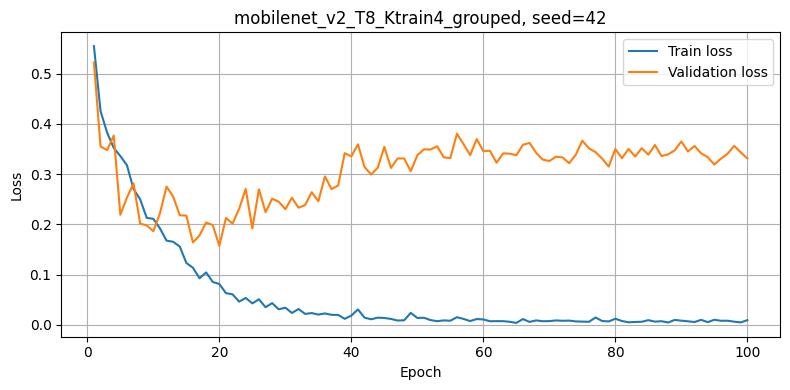

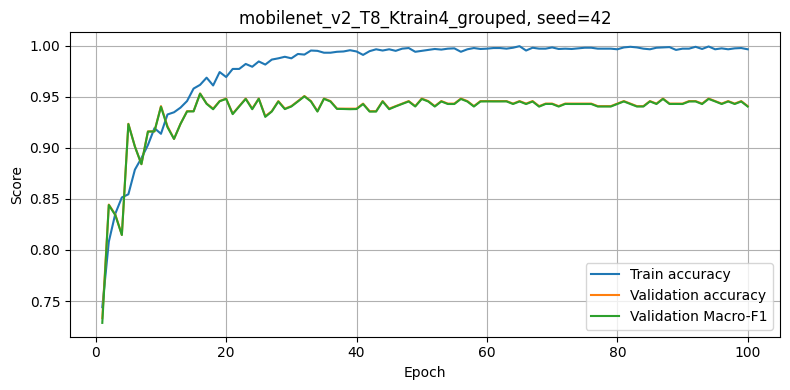

,dataset,n,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,average_precision
0,HF,100,0.9900,0.9902,0.9900,0.9900,0.9996,0.9996
1,MF,20,0.9500,0.9545,0.9500,0.9499,0.9900,0.9909
2,VCF,26,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,AVDV,35,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,SCFD,30,0.6333,0.6339,0.6333,0.6329,0.6667,0.6917
5,RLVS,200,0.9300,0.9343,0.9300,0.9298,0.9840,0.9856
6,RWF,1998,0.6186,0.6188,0.6186,0.6185,0.6647,0.6535
7,UCF,100,0.5900,0.5909,0.5900,0.5890,0.6160,0.6628
8,BV,1400,0.5286,0.5362,0.5286,0.5022,0.5410,0.5430
9,ALL_TESTS_POOLED,411,0.9343,0.9350,0.9350,0.9343,0.9807,0.9833


In [25]:
result_df = run_experiment(
    SEEDS[0]
)

display(
    result_df[
        [
            "dataset",
            "n",
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "roc_auc",
            "average_precision",
        ]
    ].round(4)
)

## 9. Fixed-T / K-test matrix evaluation

Bagian ini mengevaluasi **checkpoint yang sama** pada beberapa `K_test` sambil
mempertahankan physical/model input length `T=NATIVE_T`.

- `K_test = T` adalah native/direct test route.
- `K_test < T` menggunakan K distinct temporal positions dan mengembalikan
  sequence ke panjang T dengan equal-weight repetition.
- `grouped`: `A A B B C C D D`.
- `interleaved`: `A B C D A B C D`.
- Temporal sampling untuk evaluasi **tidak menggunakan RUN_SEED**, sehingga
  checkpoint seed 0/42/123 menerima posisi temporal yang sama.
- Untuk `K_test<T`, defaultnya 10 repeated temporal samplings.
- Source datasets dipool hanya untuk baris `SOURCE_POOLED`; RWF/UCF/BV tetap
  dilaporkan terpisah.

File `k_matrix_predictions.csv` menyimpan probabilitas per clip sehingga
paired/hierarchical bootstrap dapat dilakukan kemudian tanpa rerun inference.


In [26]:
def make_condition_loader(
    dataset_name: str,
    store,
    k_test: int,
    test_layout: str,
    repeat_id: int,
):
    feature_path, label_path, color_order = store

    ds = NpyVideoSegmentDataset(
        feature_path,
        label_path,
        indices=None,
        color_order=color_order,
        training=False,
        dataset_name=dataset_name,
        k_unique=k_test,
        repeat_layout=test_layout,
        eval_repeat_id=repeat_id,
    )

    generator = torch.Generator()
    generator.manual_seed(SAMPLING_BASE_SEED)

    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=generator,
        persistent_workers=(NUM_WORKERS > 0),
    )

def _layouts_for_k(k_test: int):
    if k_test == NUM_SEGMENTS:
        return ("native",)

    # K=1 has only one possible repetition layout.
    if k_test == 1:
        return ("grouped",)

    return tuple(EVAL_REPEAT_LAYOUTS)

def _layout_for_dataset(layout_label: str) -> str:
    return "grouped" if layout_label == "native" else layout_label

def _repeats_for_k(k_test: int):
    return 1 if k_test == NUM_SEGMENTS else K_EVAL_REPEATS

def evaluate_k_matrix(seed: int):
    run_dir = (
        OUTPUT_DIR
        / MODEL_VARIANT
        / f"seed_{seed}"
    )

    best_path = run_dir / "best.pt"

    if not best_path.exists():
        raise FileNotFoundError(
            f"Best checkpoint tidak ditemukan: {best_path}"
        )

    model = VideoMobileNetComparator(
        use_tsm=USE_TSM,
        pretrained=False,
    ).to(DEVICE)

    checkpoint = safe_torch_load(
        best_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )
    model.eval()

    criterion = nn.CrossEntropyLoss()

    matrix_dir = run_dir / "k_matrix_eval"
    matrix_dir.mkdir(parents=True, exist_ok=True)

    metrics_rows = []
    prediction_parts = []

    for k_test in K_TEST_VALUES:
        for layout_label in _layouts_for_k(k_test):
            dataset_layout = _layout_for_dataset(layout_label)

            for repeat_id in range(_repeats_for_k(k_test)):
                pooled_true = []
                pooled_pred = []
                pooled_prob = []

                for dataset_name, store in TEST_STORES.items():
                    loader = make_condition_loader(
                        dataset_name=dataset_name,
                        store=store,
                        k_test=k_test,
                        test_layout=dataset_layout,
                        repeat_id=repeat_id,
                    )

                    (
                        metrics,
                        sample_indices,
                        y_true,
                        y_pred,
                        probs,
                    ) = evaluate_loader(
                        model,
                        loader,
                        criterion,
                    )

                    row = {
                        "variant": MODEL_VARIANT,
                        "use_tsm": USE_TSM,
                        "seed": seed,
                        "native_t": NATIVE_T,
                        "k_train": K_TRAIN,
                        "train_layout": TRAIN_LAYOUT_EFFECTIVE,
                        "k_test": k_test,
                        "test_layout": layout_label,
                        "repeat_id": repeat_id,
                        "dataset": dataset_name,
                    }
                    row.update(metrics)
                    metrics_rows.append(row)

                    prediction_parts.append(
                        pd.DataFrame(
                            {
                                "variant": MODEL_VARIANT,
                                "use_tsm": USE_TSM,
                                "seed": seed,
                                "native_t": NATIVE_T,
                                "k_train": K_TRAIN,
                                "train_layout": TRAIN_LAYOUT_EFFECTIVE,
                                "k_test": k_test,
                                "test_layout": layout_label,
                                "repeat_id": repeat_id,
                                "dataset": dataset_name,
                                "sample_index": sample_indices,
                                "y_true": y_true,
                                "y_pred": y_pred,
                                "p_nonviolence": probs[:, 0],
                                "p_violence": probs[:, 1],
                            }
                        )
                    )

                    if dataset_name in POOLED_DATASETS:
                        pooled_true.append(y_true)
                        pooled_pred.append(y_pred)
                        pooled_prob.append(probs[:, 1])

                if pooled_true:
                    pooled_true_np = np.concatenate(pooled_true)
                    pooled_pred_np = np.concatenate(pooled_pred)
                    pooled_prob_np = np.concatenate(pooled_prob)

                    pooled_metrics = compute_classification_metrics(
                        pooled_true_np,
                        pooled_pred_np,
                        pooled_prob_np,
                    )

                    pooled_row = {
                        "variant": MODEL_VARIANT,
                        "use_tsm": USE_TSM,
                        "seed": seed,
                        "native_t": NATIVE_T,
                        "k_train": K_TRAIN,
                        "train_layout": TRAIN_LAYOUT_EFFECTIVE,
                        "k_test": k_test,
                        "test_layout": layout_label,
                        "repeat_id": repeat_id,
                        "dataset": "SOURCE_POOLED",
                    }
                    pooled_row.update(pooled_metrics)
                    metrics_rows.append(pooled_row)

    metrics_df = pd.DataFrame(metrics_rows)
    predictions_df = pd.concat(
        prediction_parts,
        ignore_index=True,
    )

    metrics_path = matrix_dir / "k_matrix_metrics.csv"
    predictions_path = matrix_dir / "k_matrix_predictions.csv"

    metrics_df.to_csv(
        metrics_path,
        index=False,
    )
    predictions_df.to_csv(
        predictions_path,
        index=False,
    )

    summary_metrics = [
        "accuracy",
        "f1_macro",
        "roc_auc",
        "average_precision",
    ]

    summary_df = (
        metrics_df
        .groupby(
            [
                "variant",
                "use_tsm",
                "seed",
                "native_t",
                "k_train",
                "train_layout",
                "k_test",
                "test_layout",
                "dataset",
            ],
            dropna=False,
        )[summary_metrics]
        .agg(["mean", "std"])
        .reset_index()
    )

    # Flatten MultiIndex column names for CSV portability.
    summary_df.columns = [
        "_".join(
            str(part)
            for part in col
            if str(part) != ""
        )
        if isinstance(col, tuple)
        else str(col)
        for col in summary_df.columns
    ]

    summary_path = matrix_dir / "k_matrix_summary_mean_std.csv"
    summary_df.to_csv(
        summary_path,
        index=False,
    )

    manifest = {
        "variant": MODEL_VARIANT,
        "use_tsm": USE_TSM,
        "seed": seed,
        "native_t": NATIVE_T,
        "k_train": K_TRAIN,
        "train_layout": TRAIN_LAYOUT_EFFECTIVE,
        "k_test_values": list(K_TEST_VALUES),
        "eval_repeat_layouts": list(EVAL_REPEAT_LAYOUTS),
        "k_eval_repeats": K_EVAL_REPEATS,
        "sampling_base_seed": SAMPLING_BASE_SEED,
        "sampling_seed_uses_checkpoint_seed": False,
        "source_pooled_datasets": POOLED_DATASETS,
        "heldout_datasets": HELDOUT_DATASETS,
        "interpretation": (
            "K_train=T,K_test<T is an unexpected-redundancy / train-test-mismatch test. "
            "K_train=K_test<T is matched redundancy exposure. "
            "Native-T remains a separate computational-budget condition."
        ),
    }

    with open(
        matrix_dir / "k_matrix_manifest.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            manifest,
            f,
            indent=2,
            default=json_default,
        )

    print("Saved:", metrics_path)
    print("Saved:", predictions_path)
    print("Saved:", summary_path)

    display(
        metrics_df[
            [
                "dataset",
                "k_test",
                "test_layout",
                "repeat_id",
                "average_precision",
                "roc_auc",
                "f1_macro",
                "chance_ap",
            ]
        ].head(40)
    )

    return metrics_df, predictions_df, summary_df

if RUN_K_MATRIX_EVAL:
    (
        k_matrix_metrics_df,
        k_matrix_predictions_df,
        k_matrix_summary_df,
    ) = evaluate_k_matrix(
        RUN_SEED
    )
else:
    print("RUN_K_MATRIX_EVAL=False: K-matrix evaluation dilewati.")


Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1/mobilenet_v2_T8_Ktrain4_grouped/seed_42/k_matrix_eval/k_matrix_metrics.csv
Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1/mobilenet_v2_T8_Ktrain4_grouped/seed_42/k_matrix_eval/k_matrix_predictions.csv
Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1/mobilenet_v2_T8_Ktrain4_grouped/seed_42/k_matrix_eval/k_matrix_summary_mean_std.csv


,dataset,k_test,test_layout,repeat_id,average_precision,roc_auc,f1_macro,chance_ap
0,HF,1,grouped,0,0.998800,0.998800,0.989999,0.500000
1,MF,1,grouped,0,1.000000,1.000000,0.949875,0.500000
2,VCF,1,grouped,0,0.961185,0.958580,0.845238,0.500000
3,AVDV,1,grouped,0,0.994322,0.989130,0.906667,0.657143
4,SCFD,1,grouped,0,0.657214,0.631111,0.566185,0.500000
5,RLVS,1,grouped,0,0.966383,0.960000,0.899639,0.500000
6,RWF,1,grouped,0,0.633937,0.632501,0.593552,0.499499
7,UCF,1,grouped,0,0.608664,0.554400,0.549955,0.500000
8,BV,1,grouped,0,0.544473,0.536141,0.500613,0.500000
9,SOURCE_POOLED,1,grouped,0,0.970461,0.965071,0.897795,0.513382


## 10. Complexity dan latency

Profiling selalu menggunakan **physical T**. K tidak mengurangi arithmetic workload
karena sequence tetap dipulihkan ke panjang T; inilah alasan K-test dipisahkan dari
native-T compute-budget experiment.


In [27]:
def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

@torch.inference_mode()
def benchmark_latency(
    model: nn.Module,
    warmup: int = LATENCY_WARMUP,
    runs: int = LATENCY_RUNS,
):
    model.eval()

    dummy = torch.randn(
        1,
        NUM_SEGMENTS,
        3,
        RAW_HEIGHT,
        RAW_WIDTH,
        device=DEVICE,
    )

    for _ in range(warmup):
        _ = model(dummy)

    synchronize_device()

    times_ms = []

    for _ in range(runs):
        synchronize_device()

        start = time.perf_counter()

        _ = model(dummy)

        synchronize_device()

        times_ms.append(
            (
                time.perf_counter()
                - start
            )
            * 1000.0
        )

    times_ms = np.asarray(
        times_ms,
        dtype=np.float64,
    )

    return {
        "latency_mean_ms": float(times_ms.mean()),
        "latency_std_ms": float(times_ms.std(ddof=0)),
        "latency_p50_ms": float(np.percentile(times_ms, 50)),
        "latency_p90_ms": float(np.percentile(times_ms, 90)),
        "latency_p95_ms": float(np.percentile(times_ms, 95)),
        "latency_p99_ms": float(np.percentile(times_ms, 99)),
    }

def benchmark_completed_model(
    seed: int,
):
    run_dir = (
        OUTPUT_DIR
        / MODEL_VARIANT
        / f"seed_{seed}"
    )

    checkpoint_path = (
        run_dir / "best.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

    model = VideoMobileNetComparator(
        use_tsm=USE_TSM,
        pretrained=False,
    ).to(DEVICE)

    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    total_params, trainable_params = count_parameters(
        model
    )

    result = {
        "variant": MODEL_VARIANT,
        "native_t": NATIVE_T,
        "k_train": K_TRAIN,
        "train_layout": TRAIN_LAYOUT_EFFECTIVE,
        "checkpoint_seed": seed,
        "device": str(DEVICE),
        "device_name": (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else platform.processor()
        ),
        "num_segments": NUM_SEGMENTS,
        "input_shape": [
            1,
            NUM_SEGMENTS,
            3,
            RAW_HEIGHT,
            RAW_WIDTH,
        ],
        "internal_resolution": [
            BACKBONE_INPUT_SIZE,
            BACKBONE_INPUT_SIZE,
        ],
        "tsm_blocks": model.tsm_blocks,
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
    }

    result.update(
        benchmark_latency(model)
    )

    try:
        from ptflops import (
            get_model_complexity_info
        )

        macs, params = (
            get_model_complexity_info(
                model,
                (
                    NUM_SEGMENTS,
                    3,
                    RAW_HEIGHT,
                    RAW_WIDTH,
                ),
                as_strings=False,
                print_per_layer_stat=False,
                verbose=False,
            )
        )

        result[
            "ptflops_macs"
        ] = float(macs)

        result[
            "ptflops_gmacs"
        ] = float(
            macs / 1e9
        )

        result[
            "ptflops_parameters"
        ] = float(params)

    except Exception as error:
        result[
            "ptflops_error"
        ] = repr(error)

    return result

benchmark_result = benchmark_completed_model(
    SEEDS[0]
)

display(
    pd.DataFrame(
        [benchmark_result]
    )
)

pd.DataFrame(
    [benchmark_result]
).to_csv(
    OUTPUT_DIR
    / f"benchmark_{MODEL_VARIANT}_seed{SEEDS[0]}.csv",
    index=False,
)

,variant,native_t,k_train,train_layout,checkpoint_seed,device,device_name,num_segments,input_shape,internal_resolution,...,trainable_parameters,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p90_ms,latency_p95_ms,latency_p99_ms,ptflops_macs,ptflops_gmacs,ptflops_parameters
0,mobilenet_v2_T8_Ktrain4_grouped,8,4,grouped,42,cuda,NVIDIA A100-SXM4-40GB,8,"[1, 8, 3, 64, 64]","[224, 224]",...,2226434,5.965757,0.170087,5.928352,6.08515,6.256458,6.569954,2.553377e+09,2.553377,2226434.0


## 11. Arsip hasil

In [28]:
archive_base = str(
    OUTPUT_DIR.parent
    / f"{OUTPUT_DIR.name}_results"
)

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=OUTPUT_DIR,
)

print("ZIP:", archive_path)
print("Results remain in:", OUTPUT_DIR)

ZIP: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1_results.zip
Results remain in: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_v2_T8_Ktrain4_grouped_Seed42_v1
